In [1]:
import h5py
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-darkgrid")

In [4]:
# --- Load cross section tables ---
with h5py.File("../data/PhotonScatter_total.h5", "r") as hf:
    s = hf["s"][:]
    sigma_unpol = hf["unpolarized"][:]
    sigma_polarised = {
        key: hf["polarized_"+key][:] for key in ["++++", "+++-", "++--"]
    }

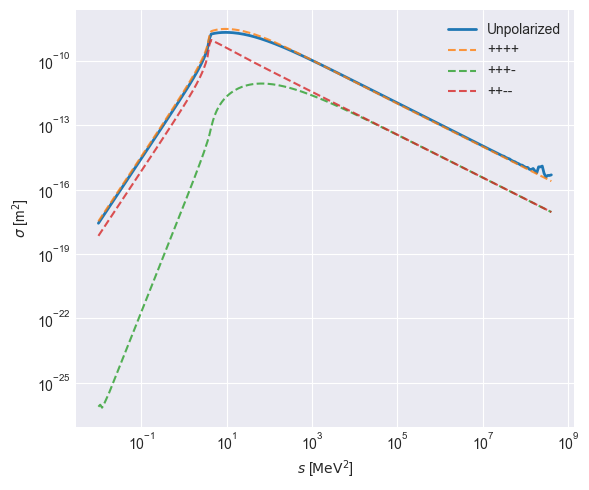

In [8]:
# === Plot total cross sections ===
plt.figure(figsize=(6, 5))
plt.loglog(s, sigma_unpol, label="Unpolarized", linewidth=2)
for key, sigma in sigma_polarised.items():
    plt.loglog(s, sigma, "--", label=f"{key}", alpha=0.8)

plt.xlabel(r"$s$ [$\mathrm{MeV}^2$]")
plt.ylabel(r"$\sigma$ [m$^2$]")
plt.legend()
plt.tight_layout()
plt.show()